In [3]:
import numpy as np
import matplotlib.pyplot as plt
import numba as nb

In [4]:
def model(x, sigma=0.1):
    return x**2 + sigma * np.random.randn(*x.shape)

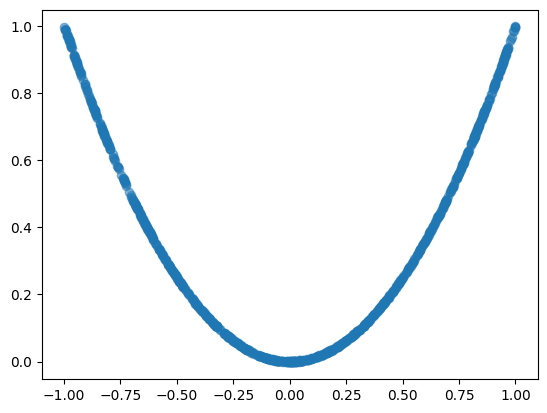

In [30]:
x = np.random.uniform(-1, 1, size=1000)
y = model(x, sigma=1.e-3)

plt.figure()
plt.scatter(x, y, alpha=0.5)   
plt.show()

In [31]:
np.corrcoef(np.array([x, y]))

array([[1.        , 0.04930069],
       [0.04930069, 1.        ]])

In [32]:
import numpy as np

def dCor(x, y):
    x = np.asarray(x)
    y = np.asarray(y)

    if x.ndim == 1:
        x = x[:, None]
    if y.ndim == 1:
        y = y[:, None]

    n = x.shape[0]

    # Distanzmatrizen
    # Distanzmatrix für X via Gram-Trick
    Gx = x @ x.T                  # Gram-Matrix
    sx = np.diag(Gx)              # quadrierte Normen
    a2 = sx[:, None] + sx[None, :] - 2 * Gx
    a2 = np.maximum(a2, 0.0)      # numerische Stabilität
    a = np.sqrt(a2)

    # Distanzmatrix für Y via Gram-Trick
    Gy = y @ y.T
    sy = np.diag(Gy)
    b2 = sy[:, None] + sy[None, :] - 2 * Gy
    b2 = np.maximum(b2, 0.0)
    b = np.sqrt(b2)

    # Doppelte Zentrierung
    A = a - a.mean(axis=1, keepdims=True) \
          - a.mean(axis=0, keepdims=True) \
          + a.mean()

    B = b - b.mean(axis=1, keepdims=True) \
          - b.mean(axis=0, keepdims=True) \
          + b.mean()

    # Quadratische Größen
    dCov2 = np.mean(A * B)
    dVarX2 = np.mean(A * A)
    dVarY2 = np.mean(B * B)

    # Numerische Stabilität
    dCov2 = max(dCov2, 0.0)
    dVarX2 = max(dVarX2, 0.0)
    dVarY2 = max(dVarY2, 0.0)

    if dVarX2 == 0 or dVarY2 == 0:
        return 0.0

    return np.sqrt(dCov2) / np.sqrt(np.sqrt(dVarX2) * np.sqrt(dVarY2))


In [33]:
dCor(x, y)

np.float64(0.4999901710755362)